In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.colors as mcolors

In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?


is_testcase = False

# Load Model Results from Disk

In [6]:
# free weights free scaling models
# omit from plots: 0.009, 0.0095, 0.0125, 0.015, 0.04, 0.0005, 0.01075, 

l_data_subset = ["full_evaluate_actual", "full_evaluate_shuffled"]
l_rnd_seed = [1]
l_embed_dim = [200]
l_lmbda = [0.0000001, 0.008, 0.01, 0.0105, 0.011, 0.012, 0.0125, 0.015, 0.025, 0.05, 0.1, 0.5, 0.9]
modeltype = "free_weights_free_scaling"
modelversion = "embeddings-decision-combined-data"

l_load = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)
l_results_fwfs = l_load[0]


# free weights no scaling models

modeltype = "free_weights_no_scaling"

l_load = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)
l_results_fwns = l_load[0]

In [7]:
def make_result_df(l):
    my_df = pd.DataFrame()
    my_df["test_accs_proba"] = l["test_accs_proba"]
    my_df["test_accs_max"] = l["test_accs_max"]
    my_df["modeltype"] = np.repeat(l["modeltype"], len(l["test_accs_proba"]))
    my_df["n_embed"] = np.repeat(l["n_embed"], len(l["test_accs_proba"]))
    my_df["lmbda"] = np.repeat(l["lmbda"], len(l["test_accs_proba"]))
    my_df["data_subset"] = np.repeat(l["data_subset"], len(l["test_accs_proba"]))
    my_df['tmp'] = l["nneg_d_over_time"]
    my_df["nneg_d_over_time"] = my_df["tmp"].astype(str).str.extract(r"\(\d+,\s*(\d+)\)")
    my_df['epoch'] = my_df["tmp"].astype(str).str.extract(r"\((\d+)")
    my_df.drop(columns=["tmp"], inplace=True)
    
    return my_df

In [8]:
l_result_dfs_fwfs = list(map(make_result_df, l_results_fwfs))
l_result_dfs_fwns = list(map(make_result_df, l_results_fwns))

In [9]:
tbl_result_df_fwfs = reduce(lambda x, y: pd.concat([x, y], axis=0), l_result_dfs_fwfs)
tbl_result_df_fwns = reduce(lambda x, y: pd.concat([x, y], axis=0), l_result_dfs_fwns)
tbl_result_df = pd.concat([tbl_result_df_fwfs, tbl_result_df_fwns], axis=0)

In [10]:
tbl_result_df = tbl_result_df.sort_values(["test_accs_max"], ascending=False)
tbl_result_df["rwn"] = tbl_result_df.groupby(["modeltype", "n_embed", "lmbda", "data_subset"]).cumcount() + 1

In [11]:
tbl_plot_results = tbl_result_df.groupby(["modeltype", "n_embed", "lmbda", "data_subset", "nneg_d_over_time"]).agg("max").reset_index()
tbl_plot_results["row_number"] = (
    tbl_plot_results
    .groupby(["modeltype", "n_embed", "lmbda", "data_subset"])
    ["test_accs_max"]
    .rank(method="first", ascending=False)
    .astype(int)
)
tbl_plot_results = tbl_plot_results.query("row_number == 1")
tbl_plot_results.drop(columns=["row_number", "epoch"], inplace=True)

In [12]:
tbl_plot_long = tbl_plot_results.melt(id_vars=["modeltype", "lmbda", "data_subset", "nneg_d_over_time"], value_vars=["test_accs_proba", "test_accs_max"])

In [13]:
tbl_plot_long.loc[tbl_plot_long["variable"] == "test_accs_proba", "variable"] = "SoftMax"
tbl_plot_long.loc[tbl_plot_long["variable"] == "test_accs_max", "variable"] = "ArgMax"

In [14]:
ordered_lmbda = sorted(tbl_plot_long["lmbda"].unique())
tbl_plot_long["lmbda_cat"] = pd.Categorical(
    tbl_plot_long["lmbda"].astype(str),
    categories=[f"{x}" for x in ordered_lmbda],
    ordered=True
)
tbl_plot_long.rename(
    columns={"modeltype":"Model", "data_subset":"Subject IDs", "nneg_d_over_time":"Nr. Dims", "value":"Accuracy"}, 
    inplace=True)
tbl_plot_long["Nr. Dims"] = tbl_plot_long["Nr. Dims"].astype(int) 


/tmp/ipykernel_3251766/3164676816.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3251766/3164676816.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


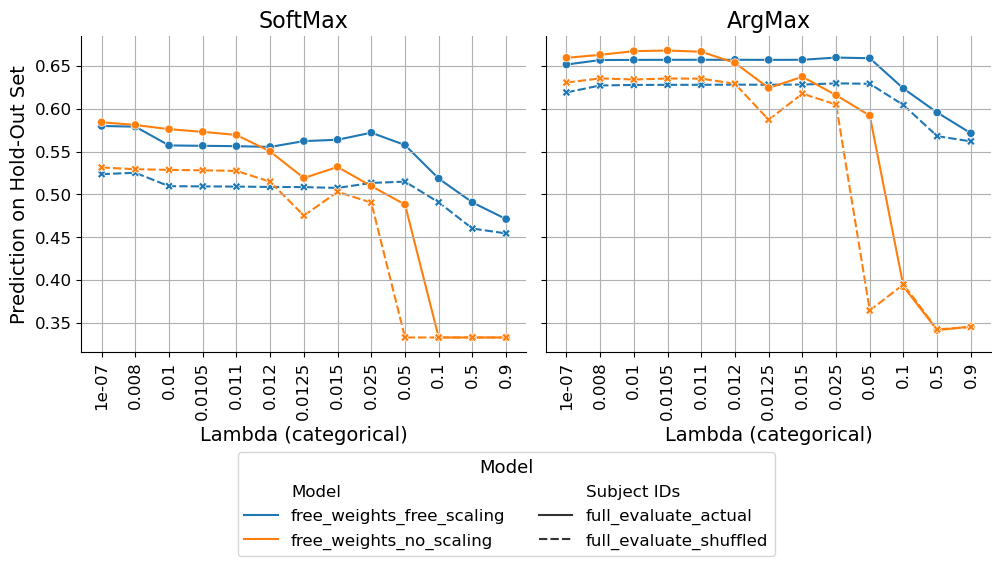

In [15]:
# Create the FacetGrid
g = sns.FacetGrid(data=tbl_plot_long, col="variable", height=5)

# Your plotting calls
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="Accuracy", style="Subject IDs", color="white", size=100, legend=False, zorder=2)
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="Accuracy", style="Subject IDs", hue="Model", legend=False, zorder=3)
g.map_dataframe(sns.lineplot, x="lmbda_cat", y="Accuracy", style="Subject IDs", hue="Model", errorbar=None, zorder=1)

# Customize each subplot
for i, (ax, title) in enumerate(zip(g.axes.flat, g.col_names)):
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Lambda (categorical)", fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel("Prediction on Hold-Out Set", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)

# Extract legend handles and labels from one subplot
handles, labels = g.axes.flat[1].get_legend_handles_labels()

# Add a shared legend below the plots, positioned lower
g.fig.legend(
    handles, labels,
    title="Model",
    loc='lower center',
    bbox_to_anchor=(0.5, -0.125),  # Move legend further down
    ncol=2,
    fontsize=12,
    title_fontsize=13
)

# Increase bottom margin to make room for the legend
g.fig.subplots_adjust(bottom=0.3)


/tmp/ipykernel_3251766/2403592175.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


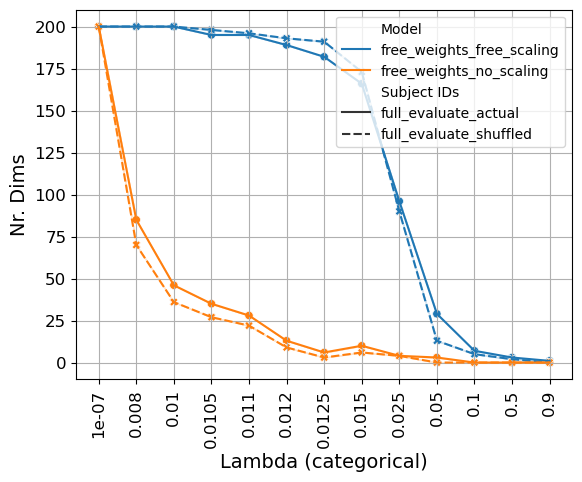

In [16]:
f, ax = plt.subplots(1)

sns.lineplot(data=tbl_plot_long, x="lmbda_cat", y="Nr. Dims", hue="Model", style="Subject IDs", ax=ax)
sns.scatterplot(data=tbl_plot_long, x="lmbda_cat", y="Nr. Dims", hue="Model", style="Subject IDs", legend=False, ax=ax)

ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Lambda (categorical)", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel("Nr. Dims", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
_ = ax.grid(True)

In [17]:
tbl_plt2 = tbl_plot_long.query("variable=='ArgMax'").melt(id_vars=["Model", "lmbda", "Subject IDs", "lmbda_cat"], value_vars=["Nr. Dims", "Accuracy"])

tbl_plt2["Model"] = tbl_plt2["Model"].astype("category")
tbl_plt2["Model"] = tbl_plt2["Model"].cat.rename_categories({
    'free_weights_free_scaling': 'Free Weights + Scaling',
    'free_weights_no_scaling': 'Free Weights Only'
})
tbl_plt2["Subject IDs"] = tbl_plt2["Subject IDs"].astype("category")
tbl_plt2["Subject IDs"] = tbl_plt2["Subject IDs"].cat.rename_categories({
    "full_evaluate_actual":"Actual",
    "full_evaluate_shuffled":"Shuffled"
})
tbl_plt2['variable'] = pd.Categorical(
    tbl_plt2['variable'],
    categories=tbl_plt2['variable'].unique()[::-1],  # reverse the order
    ordered=True
)

In [18]:
tbl_plt2.head()

,Model,lmbda,Subject IDs,lmbda_cat,variable,value
0,Free Weights + Scaling,1.000000e-07,Actual,1e-07,Nr. Dims,200.0
1,Free Weights + Scaling,1.000000e-07,Shuffled,1e-07,Nr. Dims,200.0
2,Free Weights + Scaling,8.000000e-03,Actual,0.008,Nr. Dims,200.0
3,Free Weights + Scaling,8.000000e-03,Shuffled,0.008,Nr. Dims,200.0
4,Free Weights + Scaling,1.000000e-02,Actual,0.01,Nr. Dims,200.0


In [24]:
tbl_plt2.to_pickle("highdim-plot-data.pkl")

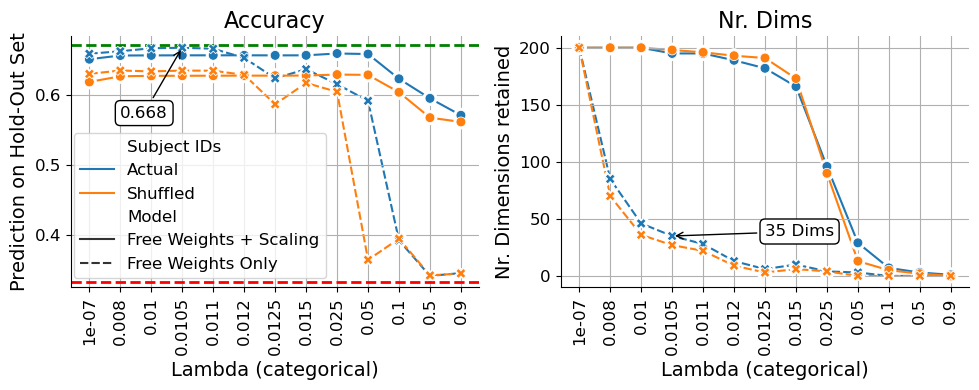

In [22]:
g = sns.FacetGrid(data=tbl_plt2, col="variable", col_wrap=2, sharey=False, height=4, aspect=1.25)

g.map_dataframe(sns.lineplot, x="lmbda_cat", y="value", hue="Subject IDs", style="Model", zorder=1)
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="value", style="Model", s=100, legend=False, color="white", zorder=2)
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="value", hue="Subject IDs", style="Model", s=50, legend=False, zorder=3)

lmbda_win = tbl_plt2.query("variable == 'Accuracy'").sort_values("value", ascending=False).reset_index(drop=True).loc[0, "lmbda_cat"]

for i, (ax, title) in enumerate(zip(g.axes.flat, g.col_names)):
    ax.grid(True)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Lambda (categorical)", fontsize=14)
    ax.set_ylabel(["Prediction on Hold-Out Set", "Nr. Dimensions retained"][i], fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.tick_params(axis="x", rotation=90)

    if i == 1:
        yval = int(tbl_plt2.query(f"variable == 'Nr. Dims' and lmbda == {lmbda_win} and `Subject IDs` == 'Actual' and Model == 'Free Weights Only'")["value"].iloc[0])
        ax.annotate(
            f"{yval} Dims",              # The label text
            xy=(lmbda_win, yval),              # The actual point in data coordinates
            xytext=("0.0125", yval),# The displaced label position
            textcoords='data',              # Use data coordinates for label
            arrowprops=dict(arrowstyle="->", color='black'),  # Arrow from label to point
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
        )

    elif i == 0:
        yval = np.round(tbl_plt2.query(f"variable == 'Accuracy' and lmbda == {lmbda_win} and `Subject IDs` == 'Actual' and Model == 'Free Weights Only'")["value"].iloc[0], 3)
        ax.annotate(
            f"{yval}",              # The label text
            xy=(lmbda_win, yval),              # The actual point in data coordinates
            xytext=("0.008", yval - .1),# The displaced label position
            textcoords='data',              # Use data coordinates for label
            arrowprops=dict(arrowstyle="->", color='black'),  # Arrow from label to point
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
        )
        line = ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
        line = ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Agreement')
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    


handles, labels = g.axes.flat[1].get_legend_handles_labels()

g.fig.legend(
    handles, labels,
    bbox_to_anchor=(0.35, 0.675),  # Move legend further down
    ncol=1,
    fontsize=12,
    title_fontsize=13
)

g.fig.tight_layout()

In [23]:
lmbda_win = tbl_plt2.query("variable == 'Accuracy'").sort_values("value", ascending=False).reset_index(drop=True).loc[0, "lmbda_cat"]

In [28]:
result = tbl_plt2.query(
    f"variable == 'Accuracy' and lmbda == {lmbda_win} and Model == 'Free Weights Only'"
).pivot(columns="Subject IDs", values="value").reset_index(drop=True)
result["Shuffled"] = result["Shuffled"].shift(-1)
result["added_accuracy"] = result["Actual"] - result["Shuffled"]

In [29]:
print(f"{result.loc[0, 'added_accuracy'] * 100:.1f} %")

3.3 %


In [31]:
result

Subject IDs,Actual,Shuffled,added_accuracy
0,0.667688,0.635071,0.032618
1,NaN,NaN,NaN


In [30]:
lmbda_win

'0.0105'